In [1]:
import json
import polars as pl
from pathlib import Path
import pandas as pd
import numpy as np
from datetime import date
import stacksats

In [2]:
btc_df = pl.read_parquet('../data/processed/bitcoin_analytics_train.parquet')

- the mvrv stat only use price_usd and mvrv -> the remain cols is not used
- technically the sopr is used to create like brk_flow, brk_roi_context, and brk_supply_pressure -> but not use in model -> stacksats/features/providers.py

stacksats/features/providers.py
- BRKOverlayFeatureProvider
    - the lagged cols at the ends - 21 columsn -> 
- CoreModelFeatureProvider

In [3]:
(
    pl.scan_parquet('../data/raw/bitcoin_analytics.parquet')
    .filter(
        (pl.col("date") >= date(2018, 1, 1)) & 
        (pl.col("date") <= date(2023, 12, 31))
    )
    .sink_parquet('../data/processed/bitcoin_analytics_train.parquet')
)
print("Filtering complete. Saved to bitcoin_analytics_filter.parquet")

Filtering complete. Saved to bitcoin_analytics_filter.parquet


# new strat with price trend

In [4]:
import polars as pl
from pathlib import Path
from stacksats import StrategyRunner, BacktestConfig, ExportConfig, UniformStrategy
from stacksats.strategy_types import BaseStrategy, StrategyContext
from stacksats.model_development import compute_preference_scores
import stacksats.framework_contract
import stacksats.runner.validation
from stacksats import MVRVStrategy


# ---------------------------------------------------------
# 0. Turn off the framework's global safety floor
# ---------------------------------------------------------
patch_val = 1e-05
stacksats.framework_contract.MIN_DAILY_WEIGHT = patch_val
stacksats.runner.validation.MIN_DAILY_WEIGHT = patch_val

# ---------------------------------------------------------
# 1. Define the Strategy (Your "Value-Investor" Logic)
# ---------------------------------------------------------
class ValueFloorStrategy(BaseStrategy):
    strategy_id = "value_floor_v2"
    version = "1.0.2"
    
    def required_feature_sets(self) -> tuple[str, ...]:
        return ("core_model_features_v1", "brk_overlay_v1")

    def build_target_profile(self, ctx: StrategyContext, features_df: pl.DataFrame, signals: dict) -> pl.DataFrame:
        
        # Get base MVRV scores
        base_scores = compute_preference_scores(
            features_df=features_df,
            start_date=ctx.start_date,
            end_date=ctx.end_date,
        )
        
        # Merge the price data
        brk_features = features_df.select(['date', 'brk_flow', 'price_usd'])
        merged = base_scores.join(brk_features, on='date', how='inner')
        
        # 1-Year Lookback
        merged = merged.with_columns(
            pl.col('price_usd').shift(365).alias('price_1y_ago')
        )
        
        # THE VALUE CONDITION: Is today's price 50% lower than 1 year ago?
        condition_price_crash = pl.col('price_usd') <= (pl.col('price_1y_ago') * 0.4)
        
        # Apply the logic
        merged = merged.with_columns(
            pl.when(condition_price_crash)
            .then(
                # CRASH DETECTED! Turn on the massive 0.8 artificial floor to buy heavily!
                pl.max_horizontal(pl.col('preference') * 2.0, pl.lit(0.6)) 
            )
            .otherwise(
                # NO CRASH. Use normal MVRV score, but dampened so we hoard cash.
                pl.max_horizontal(pl.col('preference') * 0.1, pl.lit(0.00001))
            )
            .alias('value')
        )
        
        return merged.select(['date', 'value']).fill_null(0.5)

# ---------------------------------------------------------
# 2. Setup the Data and Runner
# ---------------------------------------------------------
btc_df = pl.read_parquet('../data/processed/bitcoin_analytics_train.parquet')
btc_df = btc_df.with_columns(pl.col('date').cast(pl.Datetime))

runner = StrategyRunner()

# ---------------------------------------------------------
# 3. Calculate Score and Win Rate (Backtest tool)
# ---------------------------------------------------------
config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

print("Running New Value-Floor Strategy (2018-2023)...")
val_result = runner.backtest(ValueFloorStrategy(), config, btc_df=btc_df)
uni_result = runner.backtest(UniformStrategy(), config, btc_df=btc_df)
mvrv_result = runner.backtest(MVRVStrategy(), config, btc_df=btc_df)

print(f"-> Value-Floor Score: {val_result.score:.2f}")
print(f"-> Value-Floor Win Rate: {val_result.win_rate:.1f}%")
print(f"-> MVRV Score: {mvrv_result.score:.2f}")
print(f"-> MVRV Win Rate: {mvrv_result.win_rate:.1f}%")
print(f"-> Uniform Score: {uni_result.score:.2f}")
print(f"-> Uniform Win Rate: {uni_result.win_rate:.1f}%")

print("-" * 40)
# ---------------------------------------------------------
# 4. Calculate Exact Sats Accumulated (Export tool)
# ---------------------------------------------------------
macro_dynamic = []
mvrv_list = []
baseline_list = []

print("Calculating Total Sats Accumulated...")

for year in range(2018, 2024):
    export_config = ExportConfig(range_start=f"{year}-01-01", range_end=f"{year}-12-31")
    
    # Export all 3 strategies!
    dyn = runner.export(ValueFloorStrategy(), export_config, btc_df=btc_df).to_dataframe()
    mvrv = runner.export(MVRVStrategy(), export_config, btc_df=btc_df).to_dataframe()
    base = runner.export(UniformStrategy(), export_config, btc_df=btc_df).to_dataframe()
    
    dyn_flat = dyn.group_by('date').agg([
        pl.col('weight').mean().alias('dynamic_weight'),
        pl.col('price_usd').first()
    ])
    mvrv_flat = mvrv.group_by('date').agg([
        pl.col('weight').mean().alias('mvrv_weight')
    ])
    base_flat = base.group_by('date').agg([
        pl.col('weight').mean().alias('baseline_weight')
    ])
    
    macro_dynamic.append(dyn_flat)
    mvrv_list.append(mvrv_flat)
    baseline_list.append(base_flat)

# Combine the 6 years
dynamic_weights = pl.concat(macro_dynamic)
mvrv_weights = pl.concat(mvrv_list)
baseline_weights = pl.concat(baseline_list)

# Join them all into one massive table
merged_sats = dynamic_weights.join(baseline_weights, on='date', how='inner')
merged_sats = merged_sats.join(mvrv_weights, on='date', how='inner')

# Calculate the daily sats accumulated for all 3
merged_sats = merged_sats.with_columns(
    ((pl.col('dynamic_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_dynamic'),
    ((pl.col('mvrv_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_mvrv'),
    ((pl.col('baseline_weight') / pl.col('price_usd')) * 100_000_000).alias('sats_accumulated_baseline')
)

total_macro_sats = merged_sats["sats_accumulated_dynamic"].sum()
total_mvrv_sats = merged_sats["sats_accumulated_mvrv"].sum()
total_base_sats = merged_sats["sats_accumulated_baseline"].sum()

print(f"Total Sats (Value-Floor Strategy): {total_macro_sats:,.0f} Sats")
print(f"Total Sats (MVRV Strategy): {total_mvrv_sats:,.0f} Sats")
print(f"Total Sats (Uniform DCA): {total_base_sats:,.0f} Sats")

Running New Value-Floor Strategy (2018-2023)...
-> Value-Floor Score: 39.42
-> Value-Floor Win Rate: 46.3%
-> MVRV Score: 18.28
-> MVRV Win Rate: 31.3%
-> Uniform Score: 18.65
-> Uniform Win Rate: 0.0%
----------------------------------------
Calculating Total Sats Accumulated...
Total Sats (Value-Floor Strategy): 49,734 Sats
Total Sats (MVRV Strategy): 51,114 Sats
Total Sats (Uniform DCA): 50,551 Sats


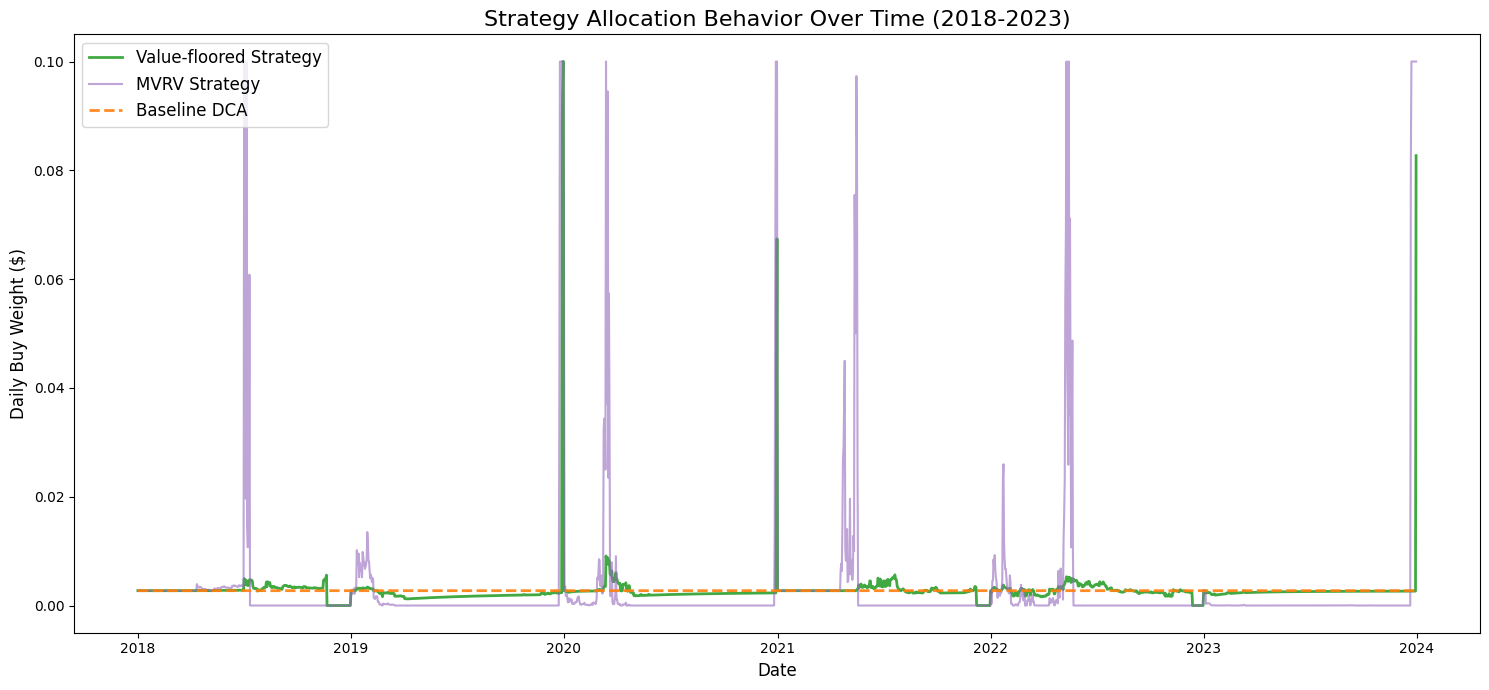

In [5]:
import matplotlib.pyplot as plt

# Make sure the table is sorted chronologically
merged_sats = merged_sats.sort('date')

# Create the chart
fig, ax1 = plt.subplots(figsize=(15, 7))

ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Daily Buy Weight ($)', fontsize=12)

# 1. Plot your Custom Tiered Strategy (Green Line)
ax1.plot(
    merged_sats['date'], merged_sats['dynamic_weight'], 
    color='tab:green', label='Value-floored Strategy', alpha=0.9, linewidth=2
)

# 2. Plot the Factory MVRV Strategy (Purple Line)
ax1.plot(
    merged_sats['date'], merged_sats['mvrv_weight'], 
    color='tab:purple', label='MVRV Strategy', alpha=0.6, linewidth=1.5
)

# 3. Plot the dumb Baseline DCA (Orange Dotted Line)
ax1.plot(
    merged_sats['date'], merged_sats['baseline_weight'], 
    color='tab:orange', label='Baseline DCA', alpha=0.9, linestyle='--', linewidth=2
)

ax1.set_title('Strategy Allocation Behavior Over Time (2018-2023)', fontsize=16)
ax1.legend(loc='upper left', fontsize=12)

plt.tight_layout()
plt.show()


## tuning

In [6]:
# import polars as pl
# from stacksats import StrategyRunner, BacktestConfig

# # ---------------------------------------------------------
# # 1. The Tunable Strategy
# # ---------------------------------------------------------
# class TunableValueStrategy(BaseStrategy):
#     # We must accept the hyperparameters when we create the class
#     def __init__(self, crash_depth, boost, floor, dampen):
#         self.crash_depth = crash_depth
#         self.boost = boost
#         self.floor = floor
#         self.dampen = dampen
        
#         # We MUST change the strategy_id dynamically so the framework doesn't cache the results!
#         self.strategy_id = f"tune_{crash_depth}_{boost}_{floor}_{dampen}"
#         self.version = "1.0.0"

#     def required_feature_sets(self) -> tuple[str, ...]:
#         return ("core_model_features_v1", "brk_overlay_v1")

#     def build_target_profile(self, ctx: StrategyContext, features_df: pl.DataFrame, signals: dict) -> pl.DataFrame:
#         base_scores = compute_preference_scores(features_df=features_df, start_date=ctx.start_date, end_date=ctx.end_date)
#         price_features = features_df.select(['date', 'price_usd'])
#         merged = base_scores.join(price_features, on='date', how='inner')
#         merged = merged.with_columns(pl.col('price_usd').shift(365).alias('price_1y_ago'))
        
#         # Inject our Hyperparameters into the Math!
#         condition_crash = pl.col('price_usd') <= (pl.col('price_1y_ago') * self.crash_depth)
        
#         merged = merged.with_columns(
#             pl.when(condition_crash)
#             .then(
#                 pl.max_horizontal(pl.col('preference') * self.boost, pl.lit(self.floor)) 
#             )
#             .otherwise(
#                 pl.max_horizontal(pl.col('preference') * self.dampen, pl.lit(0.00001))
#             )
#             .alias('value')
#         )
#         return merged.select(['date', 'value']).fill_null(0.5)

# # ---------------------------------------------------------
# # 2. The Grid Search (Hyperparameter Tuning Loop)
# # ---------------------------------------------------------
# runner = StrategyRunner()
# config = BacktestConfig(start_date="2018-01-01", end_date="2023-12-31")

# # The values you want to test! 
# # (Keep the lists short so it doesn't take 5 hours to run)
# crash_depths = [0.4, 0.5, 0.6]  # Try 40% drop, 50% drop, 60% drop
# boosts       = [2.0, 3.0, 4.0]  # Try doubling, tripling, quadrupling
# floors       = [0.6, 0.8, 1.0]  # Try moderate floor, heavy floor, absolute max floor
# dampens      = [0.1, 0.3, 0.5]  # Try heavy hoarding (0.1) vs light hoarding (0.5)

# leaderboard = []

# print(f"Starting Grid Search. Testing {len(crash_depths) * len(boosts) * len(floors) * len(dampens)} combinations...")

# for c in crash_depths:
#     for b in boosts:
#         for f in floors:
#             for d in dampens:
                
#                 # Create the strategy with the current settings
#                 strat = TunableValueStrategy(crash_depth=c, boost=b, floor=f, dampen=d)
                
#                 # Run the backtest
#                 result = runner.backtest(strat, config, btc_df=btc_df)
                
#                 # Save the results
#                 leaderboard.append({
#                     "Crash_Depth": c,
#                     "Boost": b,
#                     "Floor": f,
#                     "Dampen": d,
#                     "Score": float(result.score),
#                     "Win_Rate": float(result.win_rate)
#                 })

# # Convert leaderboard to Polars DataFrame and sort by Score
# results_df = pl.DataFrame(leaderboard).sort("Score", descending=True)

# print("\n🏆 HYPERPARAMETER GRID SEARCH WINNERS 🏆")
# display(results_df.head(10))


## math

Absolutely. The **Value-Floor Strategy** is mathematically designed to be the ultimate contrarian: it does absolutely nothing until there is blood in the streets.

Here is the exact step-by-step breakdown of how the math makes decisions:

### Step 1: The Time Machine
```python
pl.col('price_usd').shift(365).alias('price_1y_ago')
```
For every single day in the simulation, it reaches back exactly 365 days to grab the price of Bitcoin 1 year ago.

### Step 2: The "50% Crash" Detector
```python
condition_price_crash = pl.col('price_usd') <= (pl.col('price_1y_ago') * 0.5)
```
This is the core rule. We take the price from 1 year ago and multiply it by `0.5` (cutting it in half). Then we compare it to today's price.
* Let's say 1 year ago the price was **$60,000**. Half of that is **$30,000**.
* It asks: *"Is today's price less than or equal to $30,000?"*
* **If YES:** We are in a devastating crash. Bitcoin has lost 50%+ of its value in the last year.
* **If NO:** We are NOT in a devastating crash. Bitcoin might be sideways or even in a bull market.

### Step 3: The Green Light (Crash Detected!)
```python
pl.when(condition_price_crash)
.then(
    pl.max_horizontal(pl.col('preference') * 2.0, pl.lit(0.8)) 
)
```
If the math detects we are in a massive 50% crash, the traffic light turns GREEN. 
* First, we double whatever the MVRV model says (`preference * 2.0`) to make it aggressive.
* Then we apply the **Artificial Floor** using `pl.max_horizontal( ..., 0.8)`. 
* This tells the math: *"Compare the doubled score with `0.8`. Whichever is HIGHER becomes the final answer."* This mathematically guarantees that during a crash, the buy signal is massive. It forces the model to dump its cash at the absolute bottom.

### Step 4: The Red Light (Hoard Cash)
```python
.otherwise(
    pl.col('preference') * 0.5 
)
```
If the math says we are NOT in a crash (for example, during 2019, 2020, and 2021), the traffic light turns RED.
* It takes the standard MVRV score and cuts it in half (`* 0.5`).
* This forcefully dampens the model, making it too scared to buy. It hoards almost all of its cash year after year, patiently waiting for the 50% crash condition to finally trigger!

## graph

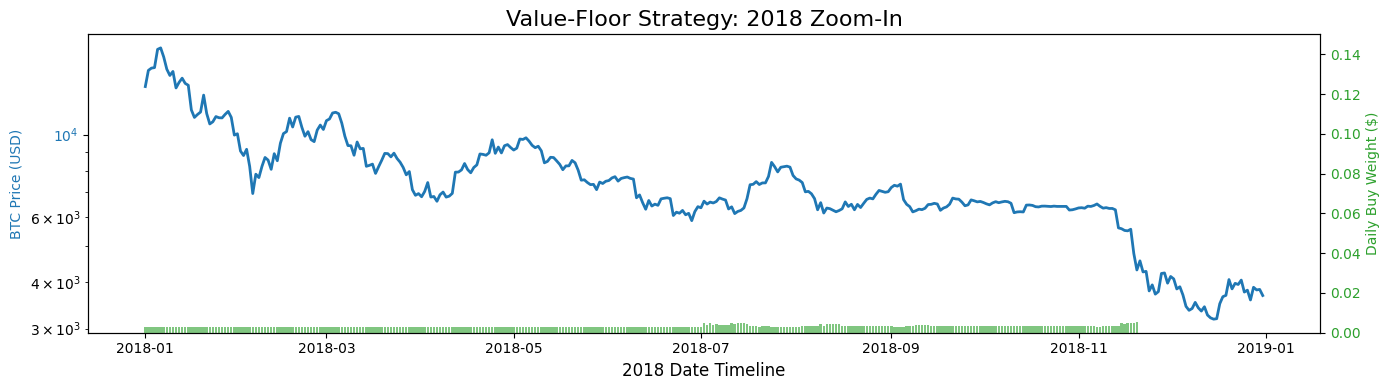

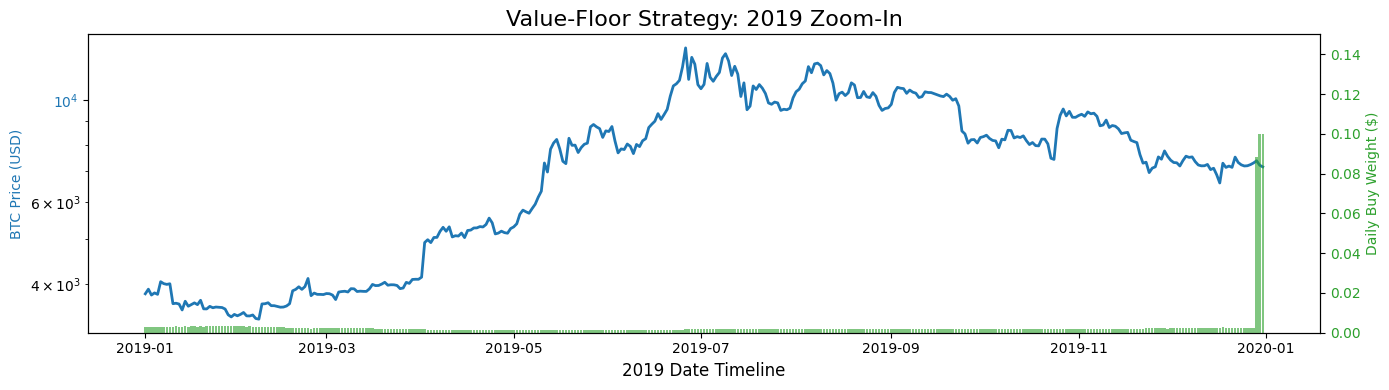

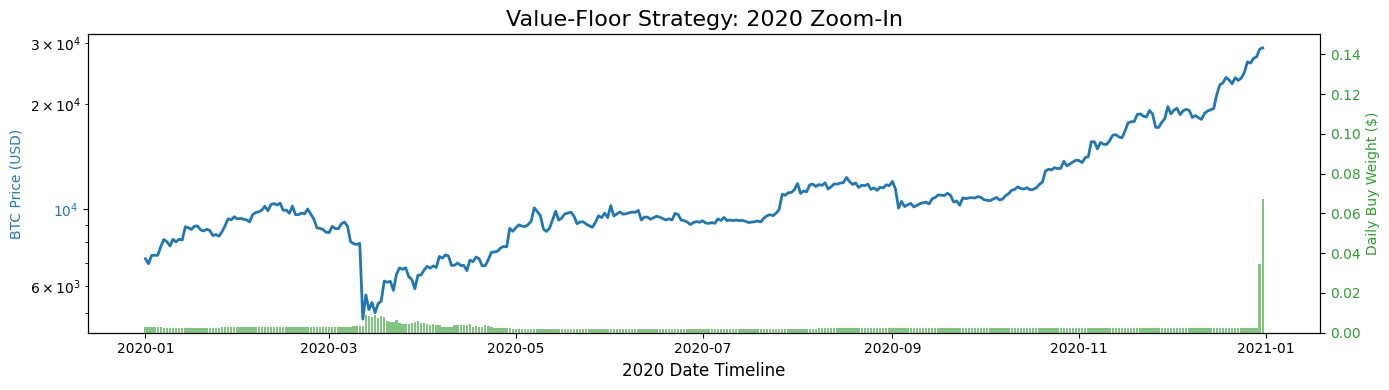

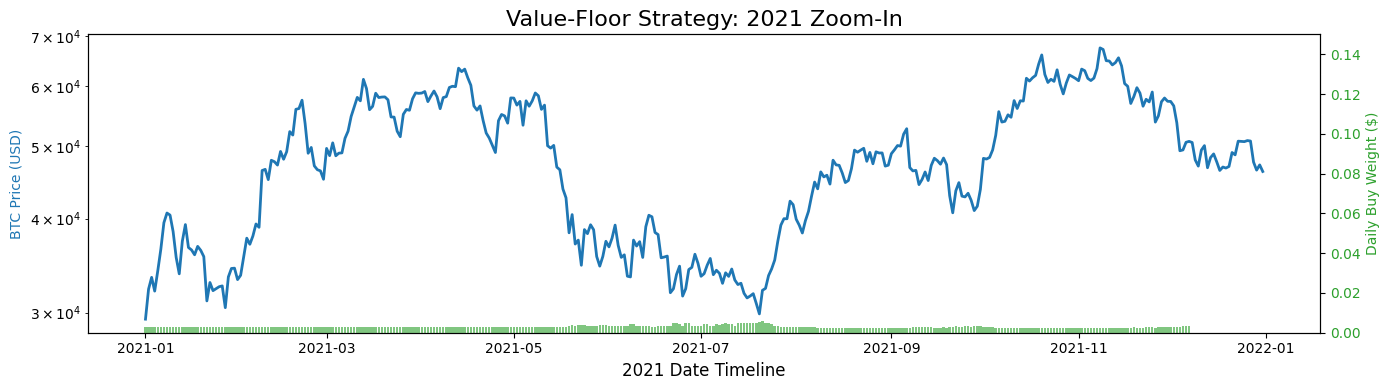

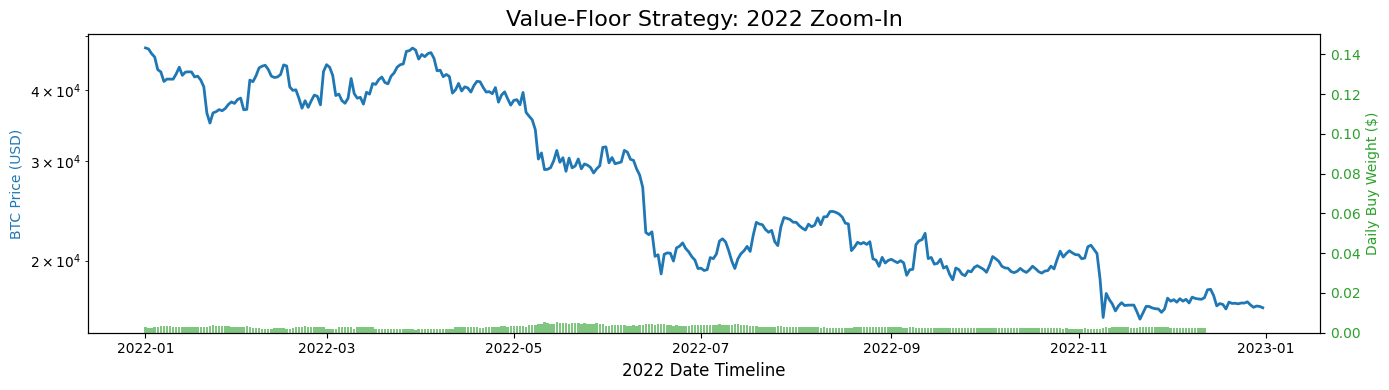

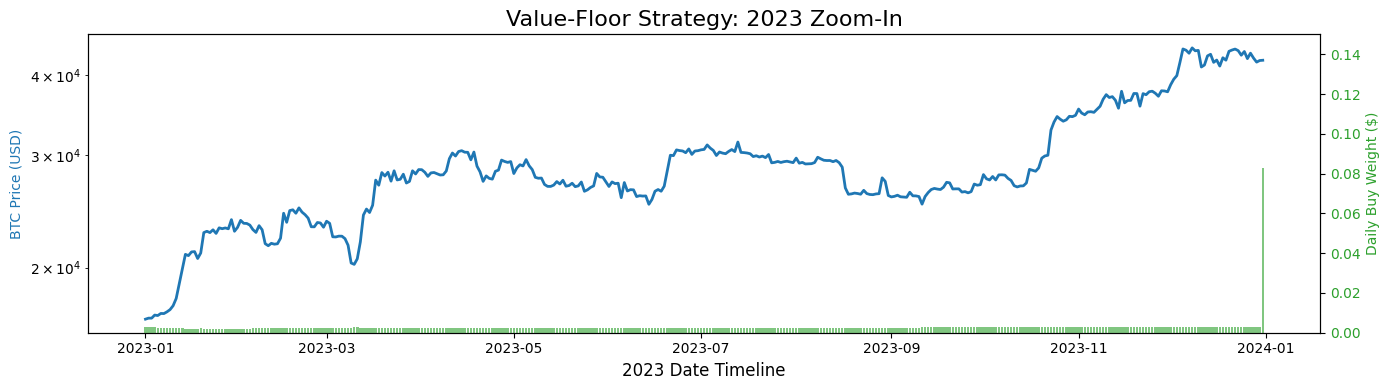

In [7]:
import matplotlib.pyplot as plt

# Make sure the table is sorted chronologically
dynamic_weights = dynamic_weights.sort('date')

# Loop through each year from 2018 to 2023
for year in range(2018, 2024):
    
    # Filter the Polars DataFrame to only keep rows from this specific year
    year_data = dynamic_weights.filter(
        pl.col('date').dt.year() == year
    )
    
    # Create the chart
    fig, ax1 = plt.subplots(figsize=(14, 4)) # Wide and short for perfect scrolling

    # 1. Plot Bitcoin Price (Left Axis - Log Scale)
    color = 'tab:blue'
    ax1.set_xlabel(f'{year} Date Timeline', fontsize=12)
    ax1.set_ylabel('BTC Price (USD)', color=color)
    ax1.plot(year_data['date'], year_data['price_usd'], color=color, linewidth=2)
    ax1.set_yscale('log')
    ax1.tick_params(axis='y', labelcolor=color)

    # 2. Plot Strategy Buying Weights (Right Axis - Bar Chart)
    ax2 = ax1.twinx()
    color = 'tab:green'
    ax2.set_ylabel('Daily Buy Weight ($)', color=color)
    ax2.bar(year_data['date'], year_data['dynamic_weight'], color=color, alpha=0.6)
    
    # Optional: We lock the Y-axis maximum at $0.15 (15 cents) for all charts 
    # so the green bars are visually proportional across all years
    ax2.set_ylim(0, 0.15) 
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(f'Value-Floor Strategy: {year} Zoom-In', fontsize=16)
    fig.tight_layout()
    plt.show()
